In [1]:
# Localized 3D binary classification on chest CT cubes
import random
import warnings
from dataclasses import dataclass
from importlib import reload
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
 )
from torch.utils.data import DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore")

import datasets as datasets_module
reload(datasets_module)
from pre_process_data import PreProcessData
from datasets import CTCubeDataset3D, resolve_volume_path

In [2]:
@dataclass
class Config:
    project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
    exp1_path = project_root / "data" / "Experiment 1 - Blind"
    exp2_path = project_root / "data" / "Experiment 2 - Open"

    exp1_labels_csv = project_root / "data" / "labels_exp1.csv"
    exp2_labels_csv = project_root / "data" / "labels_exp2.csv"

    export_root = project_root / "processed_dataset"
    combined_csv = export_root / "combined_labels.csv"
    train_csv = export_root / "train_labels.csv"
    test_csv = export_root / "test_labels.csv"

    train_cube_csv = export_root / "train_cubes_3d.csv"
    val_cube_csv = export_root / "val_cubes_3d.csv"
    test_cube_csv = export_root / "test_cubes_3d.csv"
    scan_manifest_csv = export_root / "scan_manifest.csv"

    # Model weights output directory
    weights_dir = project_root / "model_weights"
    cube_weights_path = weights_dir / "local_cube_3d_cnn.pt"

    volume_key = "volume"
    patch_size = 32
    jitter_px = 2
    augment_train = True
    augment_eval = False

    # Retained for earlier exploratory patch visualisations above
    expand_depth = 3
    tb_slices_per_uuid = 15
    tb_coords_per_slice = 3

    # Localized 3D cube configuration
    cube_depth = 5
    cube_patch_size = 32
    cube_jitter_xy = 2
    cube_jitter_z = 1
    cube_train_center_shifts = (-1, 0, 1)
    cube_eval_center_shifts = (0,)
    tb_negative_slices_per_uuid = 5
    tb_negative_coords_per_slice = 3

    cube_batch_size = 24
    cube_epochs = 60
    cube_lr = 3e-4
    cube_weight_decay = 1e-4
    val_size = 0.2
    test_size = 0.2

    cube_early_stop_patience = 15
    cube_min_delta = 1e-4

    cosine_T0 = 8
    cosine_T_mult = 2
    cosine_eta_min = 1e-6

    seed = 6767

    device = (
        "mps" if torch.backends.mps.is_available()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )

CFG = Config()

print(f"Project root:        {CFG.project_root}")
print(f"Device:              {CFG.device}")
print(f"Cube size:           ({CFG.cube_depth}, {CFG.cube_patch_size}, {CFG.cube_patch_size})")
print(f"Cube batch size:     {CFG.cube_batch_size}")
print(f"Cube epochs:         {CFG.cube_epochs}")
print(f"Validation size:     {CFG.val_size}")
print(f"Test size:           {CFG.test_size}")
print(f"Weights path:        {CFG.cube_weights_path}")

Project root:        /Users/ningkaiyang/Desktop/CS 172B Project
Device:              mps
Cube size:           (5, 32, 32)
Cube batch size:     24
Cube epochs:         60
Validation size:     0.2
Test size:           0.2
Weights path:        /Users/ningkaiyang/Desktop/CS 172B Project/model_weights/local_cube_3d_cnn.pt


In [3]:
# Reproducibility
random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
torch.cuda.manual_seed_all(CFG.seed)

# Use deterministic behavior where possible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Preprocessing
This cell converts DICOM folders into per-patient `volume.npz` files only when needed, then merges labels from both experiments into one table.

In [4]:
def preprocess_and_merge_labels(cfg: Config) -> pd.DataFrame:
    cfg.export_root.mkdir(parents=True, exist_ok=True)

    exp1_df = pd.read_csv(cfg.exp1_labels_csv).copy()
    exp2_df = pd.read_csv(cfg.exp2_labels_csv).copy()

    exp1_df["source"] = "exp1"
    exp2_df["source"] = "exp2"

    all_df = pd.concat([exp1_df, exp2_df], ignore_index=True)
    expected_uuids = set(all_df["uuid"].astype(str).unique())

    def _all_processed() -> bool:
        if not cfg.combined_csv.exists():
            return False
        for uuid in expected_uuids:
            if not (cfg.export_root / uuid / "volume.npz").exists():
                return False
        return True

    if _all_processed():
        print("Processed volumes and combined labels already exist. Skipping preprocessing.")
        return pd.read_csv(cfg.combined_csv)

    print("Running preprocessing for missing outputs...")
    if cfg.exp1_path.exists():
        PreProcessData(cfg.exp1_path, cfg.export_root).run()
    if cfg.exp2_path.exists():
        PreProcessData(cfg.exp2_path, cfg.export_root).run()

    combined_df = pd.concat([exp1_df, exp2_df], ignore_index=True).drop_duplicates()
    combined_df["uuid"] = combined_df["uuid"].astype(str)
    combined_df.to_csv(cfg.combined_csv, index=False)
    print(f"Saved merged labels: {cfg.combined_csv} ({len(combined_df)} rows)")
    return combined_df

combined_df = preprocess_and_merge_labels(CFG)
combined_df.head()

Processed volumes and combined labels already exist. Skipping preprocessing.


,type,uuid,slice,x,y,source
0,FB,1280,100,323,381,exp1
1,FB,1009,76,354,288,exp1
2,FB,7794,79,163,191,exp1
3,FB,7794,94,338,243,exp1
4,FB,2997,45,156,135,exp1


In [5]:
# Dataset inspection: processed volume availability and shape summary
uuid_dirs = sorted([p for p in CFG.export_root.iterdir() if p.is_dir()])
print(f"Processed subject folders: {len(uuid_dirs)}")

missing_npz = [p.name for p in uuid_dirs if not (p / "volume.npz").exists()]
print(f"Folders missing volume.npz: {len(missing_npz)}")

shape_rows: List[Dict] = []
for folder in uuid_dirs[:8]:
    vpath = folder / "volume.npz"
    if not vpath.exists():
        continue
    vol = np.load(vpath, allow_pickle=False)[CFG.volume_key]
    shape_rows.append({
        "uuid": folder.name,
        "shape": vol.shape,
        "min": float(vol.min()),
        "max": float(vol.max()),
        "mean": float(vol.mean()),
    })

shape_df = pd.DataFrame(shape_rows)
shape_df

Processed subject folders: 98
Folders missing volume.npz: 0


,uuid,shape,min,max,mean
0,1003,"(481, 512, 512)",0.0,1.0,0.330555
1,1005,"(471, 512, 512)",0.0,1.0,0.365006
2,1009,"(133, 512, 512)",0.0,1.0,0.339640
3,1045,"(280, 512, 512)",0.0,1.0,0.306051
4,1067,"(328, 512, 512)",0.0,1.0,0.277476
5,1201,"(133, 512, 512)",0.0,1.0,0.350304
6,1219,"(144, 512, 512)",0.0,1.0,0.274296
7,1251,"(330, 512, 512)",0.0,1.0,0.381144


## Annotation Expansion

Each raw CSV row covers a single annotated slice. We expand every annotation into a window of **centre ± `expand_depth` slices** (clamped to volume bounds) so that neighbouring slices that also contain the nodule contribute training signal.

**TB special case** – TB rows carry `(slice=0, x=0, y=0)`, encoding a volume-level label ("this whole volume is benign / untampered"). There is no single annotated coordinate, so instead we:
- Deduplicate TB entries to one row per unique UUID (same volume can appear multiple times).
- Randomly sample `tb_slices_per_uuid` uniformly-distributed slices across the full volume depth.
- For each sampled slice, pick `tb_coords_per_slice` random `(x,y)` positions, keeping each crop at least `patch_size // 2` pixels from the image border.

**Redundancy note** – Because consecutive rows come from overlapping slices of the same volume, they are not independent. The *subject-level* train/test split applied later prevents any volume from appearing in both sets, so there is no data leakage even though individual rows are correlated.

**Optional negatives** – Slices ≥10 away from every positive annotation could be flagged as "weak negatives". However, given that the TB expansion already provides many standard-tissue patches, this is omitted to avoid further label noise.

In [6]:
def expand_annotations(
    df: pd.DataFrame,
    cfg: Config,
    depth: int = 3,
    tb_slices_per_uuid: int = 15,
    tb_coords_per_slice: int = 3,
    seed: int = 42,
) -> pd.DataFrame:
    """Expand single-slice annotations to neighbouring slices.

    Normal rows (FB / FM / TM):
        Replicate the row for slices [z-depth, ..., z+depth], clamped to
        the actual volume depth.  Coordinates (x, y) are carried over
        unchanged; any augmentation-jitter still applied at load time avoids
        exact pixel-level duplicates.

    TB rows (slice=0, x=0, y=0):
        These are volume-level labels ("whole volume is benign").
        - One row per unique UUID is processed (duplicates within the CSV are
          deduplicated so each volume is sampled only once).
        - `tb_slices_per_uuid` slices are drawn uniformly at random from [0, Z).
        - For each slice, `tb_coords_per_slice` random (x,y) positions are
          chosen, staying at least patch_size//2 pixels from the image border.

    Assumptions
    -----------
    * All volumes exist under cfg.export_root/<uuid>/volume.npz.
    * The (x, y) convention in the CSV is consistent with the image array
      indexing used in CTPatchDataset; no axis swap is needed.
    * Consecutive expanded rows share anatomy and are therefore correlated —
      the downstream subject-level split prevents leakage between train and test.
    """
    rng = np.random.default_rng(seed)
    half = cfg.patch_size // 2

    is_tb_corner = (
        (df["type"] == "TB") &
        (df["slice"] == 0) &
        (df["x"] == 0) &
        (df["y"] == 0)
    )
    normal_df = df[~is_tb_corner].copy()
    tb_df     = df[is_tb_corner].copy()

    rows: List[dict] = []

    # ── Normal annotations: expand ±depth slices ─────────────────────────────
    vol_cache: Dict[str, int] = {}  # uuid → Z depth (int only; avoid holding full array)

    for _, row in normal_df.iterrows():
        uuid = str(row["uuid"])
        if uuid not in vol_cache:
            vpath = cfg.export_root / uuid / "volume.npz"
            if not vpath.exists():
                print(f"  WARNING: missing {vpath} — skipping")
                continue
            v = np.load(vpath, mmap_mode="r", allow_pickle=False)[cfg.volume_key]
            vol_cache[uuid] = v.shape  # (Z, H, W)

        Z, H, W = vol_cache[uuid]
        z_center = int(row["slice"])
        for dz in range(-depth, depth + 1):
            z = z_center + dz
            if not (0 <= z < Z):
                continue
            r = row.to_dict()
            r["slice"] = z
            rows.append(r)

    # ── TB / corner annotations: random patches across the full volume ────────
    seen_tb_uuids: set = set()
    for _, row in tb_df.iterrows():
        uuid = str(row["uuid"])
        if uuid in seen_tb_uuids:
            continue  # one expansion per volume (CSV may have duplicates)
        seen_tb_uuids.add(uuid)

        vpath = cfg.export_root / uuid / "volume.npz"
        if not vpath.exists():
            print(f"  WARNING: missing {vpath} (TB) — skipping")
            continue
        v = np.load(vpath, mmap_mode="r", allow_pickle=False)[cfg.volume_key]
        Z, H, W = v.shape

        chosen_z = rng.integers(0, Z, size=tb_slices_per_uuid)
        for z in chosen_z:
            for _ in range(tb_coords_per_slice):
                x = int(rng.integers(half, W - half))
                y = int(rng.integers(half, H - half))
                r = row.to_dict()
                r["slice"] = int(z)
                r["x"] = x
                r["y"] = y
                rows.append(r)

    expanded = pd.DataFrame(rows).reset_index(drop=True)
    expanded["uuid"] = expanded["uuid"].astype(str)

    print(
        f"Annotation expansion: {len(df)} raw rows → {len(expanded)} expanded rows\n"
        f"  Normal annotations (depth ±{depth}): {len(normal_df)} → "
        f"{len(expanded) - len(seen_tb_uuids) * tb_slices_per_uuid * tb_coords_per_slice} rows\n"
        f"  TB volumes re-sampled ({tb_slices_per_uuid} slices × {tb_coords_per_slice} coords): "
        f"{len(seen_tb_uuids)} unique UUIDs → "
        f"{len(seen_tb_uuids) * tb_slices_per_uuid * tb_coords_per_slice} rows"
    )

    return expanded


# Apply expansion to the merged labels
expanded_df = expand_annotations(
    combined_df,
    CFG,
    depth=CFG.expand_depth,
    tb_slices_per_uuid=CFG.tb_slices_per_uuid,
    tb_coords_per_slice=CFG.tb_coords_per_slice,
    seed=CFG.seed,
)
print("\n4-class distribution after expansion:")
print(expanded_df["type"].value_counts().sort_index())
expanded_df.head(10)


Annotation expansion: 163 raw rows → 1711 expanded rows
  Normal annotations (depth ±3): 148 → 1036 rows
  TB volumes re-sampled (15 slices × 3 coords): 15 unique UUIDs → 675 rows

4-class distribution after expansion:
type
FB    504
FM    287
TB    675
TM    245
Name: count, dtype: int64


,type,uuid,slice,x,y,source
0,FB,1280,97,323,381,exp1
1,FB,1280,98,323,381,exp1
2,FB,1280,99,323,381,exp1
3,FB,1280,100,323,381,exp1
4,FB,1280,101,323,381,exp1
5,FB,1280,102,323,381,exp1
6,FB,1280,103,323,381,exp1
7,FB,1009,73,354,288,exp1
8,FB,1009,74,354,288,exp1
9,FB,1009,75,354,288,exp1


UUID=1876  type=FB  annotated (z,x,y)=(144,414,181)
Volume shape: Z=308, H=512, W=512
Showing slices: [141, 142, 143, 144, 145, 146, 147]


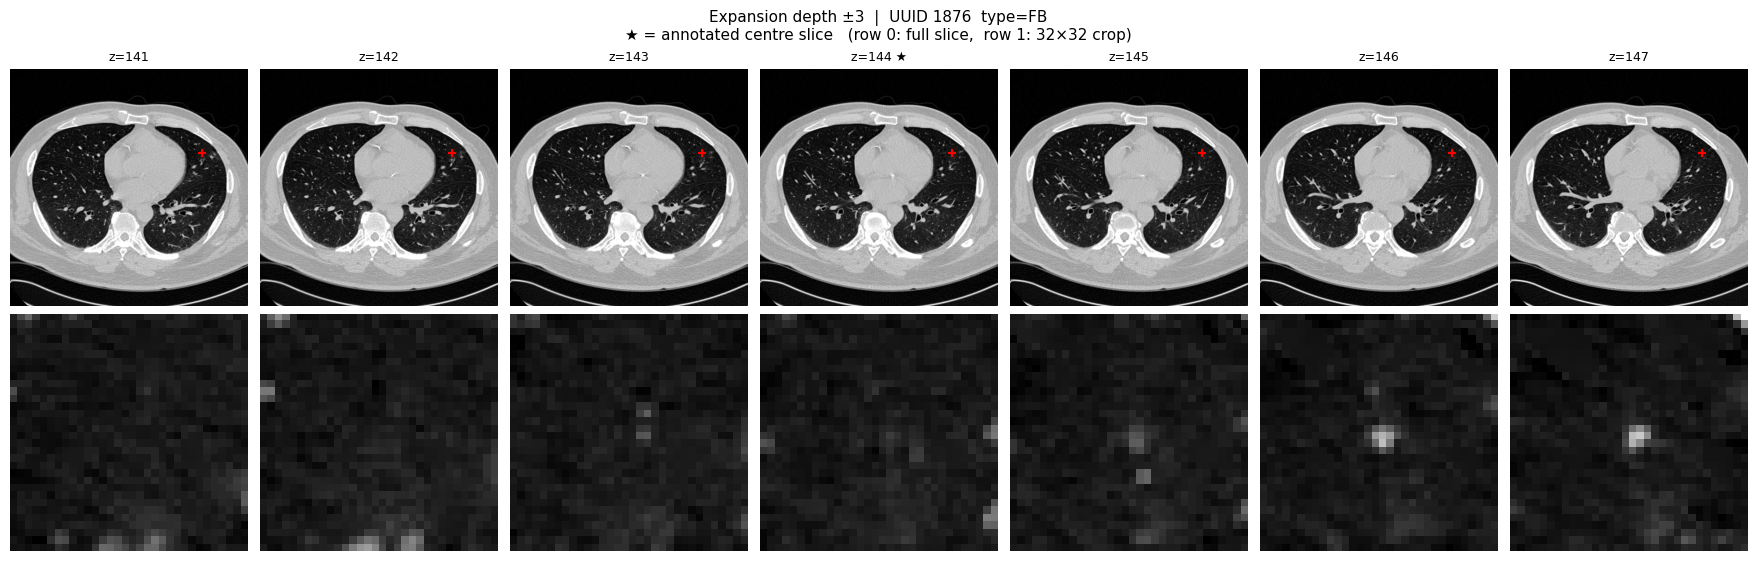

In [7]:
# ── Visualise expansion: full slices + 32×32 patches at z_center ± depth ─────
# Pick one non-TB annotation to demonstrate the expansion
vis_row = expanded_df[expanded_df["type"] != "TB"].sample(n=1, random_state=1).iloc[0]
vis_uuid   = str(vis_row["uuid"])
vis_z_orig = int(vis_row["slice"])
vis_x      = int(vis_row["x"])
vis_y      = int(vis_row["y"])
vis_type   = str(vis_row["type"])

vol_vis = np.load(CFG.export_root / vis_uuid / "volume.npz", allow_pickle=False)[CFG.volume_key]
z_indices_vis = [
    z for z in range(vis_z_orig - CFG.expand_depth, vis_z_orig + CFG.expand_depth + 1)
    if 0 <= z < vol_vis.shape[0]
]

n_z = len(z_indices_vis)
half_p = CFG.patch_size // 2

print(f"UUID={vis_uuid}  type={vis_type}  annotated (z,x,y)=({vis_z_orig},{vis_x},{vis_y})")
print(f"Volume shape: Z={vol_vis.shape[0]}, H={vol_vis.shape[1]}, W={vol_vis.shape[2]}")
print(f"Showing slices: {z_indices_vis}")

fig, axes = plt.subplots(2, n_z, figsize=(2.5 * n_z, 5.5), constrained_layout=True)
if n_z == 1:
    axes = axes.reshape(2, 1)

for col, z in enumerate(z_indices_vis):
    slc = vol_vis[z]
    H, W = slc.shape

    # Row 0: full slice with crosshair
    axes[0, col].imshow(slc, cmap="gray", vmin=0, vmax=1)
    axes[0, col].scatter([vis_x], [vis_y], c="red", s=30, marker="+")
    axes[0, col].set_title(f"z={z}" + (" ★" if z == vis_z_orig else ""), fontsize=9)
    axes[0, col].axis("off")

    # Row 1: 32×32 patch centred on (vis_x, vis_y)
    y0 = max(vis_y - half_p, 0);  y1 = min(vis_y + half_p, H)
    x0 = max(vis_x - half_p, 0);  x1 = min(vis_x + half_p, W)
    patch_vis = slc[y0:y1, x0:x1]
    axes[1, col].imshow(patch_vis, cmap="gray", vmin=0, vmax=1)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Full slice", fontsize=8)
axes[1, 0].set_ylabel(f"{CFG.patch_size}×{CFG.patch_size} patch", fontsize=8)
plt.suptitle(
    f"Expansion depth ±{CFG.expand_depth}  |  UUID {vis_uuid}  type={vis_type}\n"
    "★ = annotated centre slice   (row 0: full slice,  row 1: 32×32 crop)",
    fontsize=11,
)
plt.show()


## Labels and Binary Target

### Semantic clarification

The four original labels map as follows:

| Label | Meaning | Standard/Tampered |
|-------|---------|:---:|
| `TB` | True Benign | **Standard (untampered)** |
| `TM` | True Malignant | **Standard (untampered)** |
| `FB` | False Benign | **Tampered** |
| `FM` | False Malignant | **Tampered** |

**Standard = TB, TM** (untampered)
**Tampered = FB, FM**

### Why accuracy is misleading here

The expanded dataset contains roughly 54% standard scans. A dummy classifier that always predicts **standard** will achieve ~54% accuracy without learning anything. We therefore also track **F1 (macro)** and **ROC-AUC** which both penalise ignoring the tampered class, and we use a weighted loss and a balanced sampler to force the model to actually learn tampered-scan features.

In [8]:
# Work on the expanded dataframe produced above.
# 'source' column is already set by preprocess_and_merge_labels; preserve it.
work_df = expanded_df.copy()
work_df["uuid"] = work_df["uuid"].astype(str)

# 4-class distribution after expansion
class_counts = work_df["type"].value_counts().sort_index()
print("4-class distribution (expanded):")
print(class_counts)

# Binary mapping:
#   0 = Standard (untampered)  → TB, TM
#   1 = Tampered               → FB, FM
binary_map = {"TB": 0, "TM": 0, "FB": 1, "FM": 1}
work_df["target"] = work_df["type"].map(binary_map)

if work_df["target"].isna().any():
    bad = work_df.loc[work_df["target"].isna(), "type"].unique()
    raise ValueError(f"Found unknown labels in 'type': {bad}")

print("\nBinary distribution (expanded):")
print(
    work_df["target"].value_counts().sort_index()
    .rename({0: "0=Standard", 1: "1=Tampered"})
)

# pos_weight = #negative / #positive  (used in BCEWithLogitsLoss)
n_neg = int((work_df["target"] == 0).sum())
n_pos = int((work_df["target"] == 1).sum())
pos_weight_val = n_neg / n_pos
print(f"\nn_standard={n_neg}  n_tampered={n_pos}  pos_weight={pos_weight_val:.3f}")

work_df.head()


4-class distribution (expanded):
type
FB    504
FM    287
TB    675
TM    245
Name: count, dtype: int64

Binary distribution (expanded):
target
0=Standard    920
1=Tampered    791
Name: count, dtype: int64

n_standard=920  n_tampered=791  pos_weight=1.163


,type,uuid,slice,x,y,source,target
0,FB,1280,97,323,381,exp1,1
1,FB,1280,98,323,381,exp1,1
2,FB,1280,99,323,381,exp1,1
3,FB,1280,100,323,381,exp1,1
4,FB,1280,101,323,381,exp1,1


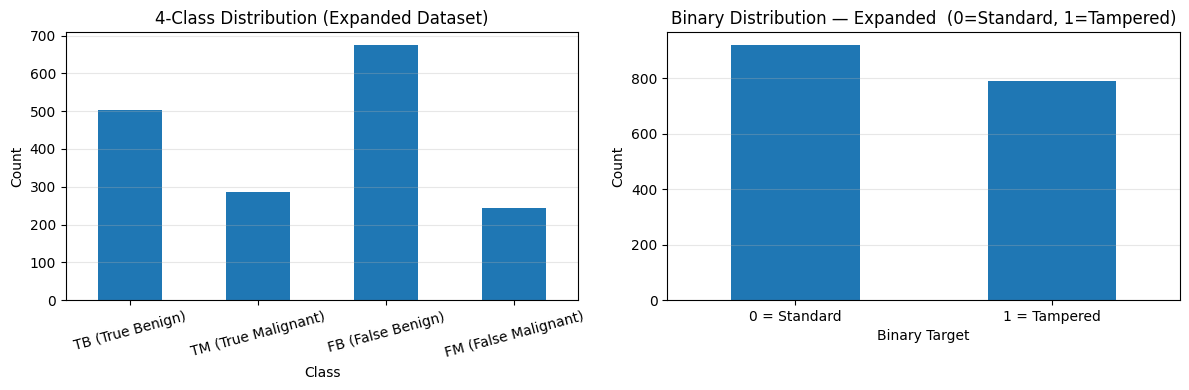

Majority-class fraction (expanded): 53.8 %


In [9]:
# Visualize 4-class and binary distributions (after expansion)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts.plot(kind="bar", ax=axes[0], title="4-Class Distribution (Expanded Dataset)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_xticklabels(["TB (True Benign)", "TM (True Malignant)", "FB (False Benign)", "FM (False Malignant)"], rotation=15)

work_df["target"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], title="Binary Distribution — Expanded  (0=Standard, 1=Tampered)"
)
axes[1].set_xlabel("Binary Target")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["0 = Standard", "1 = Tampered"], rotation=0)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

majority_pct = work_df["target"].value_counts(normalize=True).max() * 100
print(f"Majority-class fraction (expanded): {majority_pct:.1f} %")


## Train / Validation / Test Split and Localized 3D Cube Dataset

From this point onward, the pipeline switches from whole-scan supervision to **localized 3D cube classification**. The key changes are:

1. Each scan is still identified by **`(source, uuid)`** so repeated UUIDs across experiments do not collide.
2. The 3D CNN now sees a small cube centered on a candidate point `(slice, x, y)` rather than an entire scan.
3. We keep **scan-level train / validation / test splits** to prevent leakage, but create many cubes inside each split.
4. `FB` / `FM` become tampered cubes, `TM` becomes localized standard cubes, and `TB` contributes sampled standard cubes with random benign locations.

In [10]:
def build_scan_manifest(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """Build one binary-labeled row per unique (source, uuid) scan."""
    binary_map = {"TB": 0, "TM": 0, "FB": 1, "FM": 1}
    manifest_rows: List[Dict] = []

    base_df = df.copy()
    base_df["uuid"] = base_df["uuid"].astype(str)
    base_df["source"] = base_df["source"].astype(str)
    base_df["scan_id"] = base_df["source"] + "_" + base_df["uuid"]
    base_df["target"] = base_df["type"].map(binary_map)

    if base_df["target"].isna().any():
        bad = sorted(base_df.loc[base_df["target"].isna(), "type"].astype(str).unique().tolist())
        raise ValueError(f"Unknown label types found while building scan manifest: {bad}")

    for (source, uuid), group in base_df.groupby(["source", "uuid"], sort=True):
        targets = sorted(group["target"].astype(int).unique().tolist())
        if len(targets) != 1:
            raise ValueError(
                f"Inconsistent binary targets for source={source}, uuid={uuid}: {targets}"
            )

        label_types = sorted(group["type"].astype(str).unique().tolist())
        volume_path = resolve_volume_path(cfg.export_root, uuid, source)
        volume_shape = np.load(volume_path, mmap_mode="r", allow_pickle=False)[cfg.volume_key].shape

        manifest_rows.append(
            {
                "scan_id": f"{source}_{uuid}",
                "source": source,
                "uuid": uuid,
                "target": int(targets[0]),
                "type_labels": "|".join(label_types),
                "n_rows": int(len(group)),
                "depth": int(volume_shape[0]),
                "height": int(volume_shape[1]),
                "width": int(volume_shape[2]),
            }
        )

    return pd.DataFrame(manifest_rows).sort_values("scan_id").reset_index(drop=True)


def stratified_scan_split(
    scan_df: pd.DataFrame,
    val_size: float,
    test_size: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    train_parts: List[pd.DataFrame] = []
    val_parts: List[pd.DataFrame] = []
    test_parts: List[pd.DataFrame] = []

    for cls in sorted(scan_df["target"].astype(int).unique().tolist()):
        cls_df = scan_df[scan_df["target"] == cls].sample(frac=1.0, random_state=seed + cls).reset_index(drop=True)
        n_total = len(cls_df)
        if n_total < 3:
            raise ValueError(f"Need at least 3 scans in class {cls}, found {n_total}")

        n_test = max(1, int(round(n_total * test_size)))
        n_val = max(1, int(round(n_total * val_size)))

        while n_test + n_val > n_total - 1:
            if n_val >= n_test and n_val > 1:
                n_val -= 1
            elif n_test > 1:
                n_test -= 1
            else:
                break

        indices = np.arange(n_total)
        rng.shuffle(indices)
        test_idx = indices[:n_test]
        val_idx = indices[n_test:n_test + n_val]
        train_idx = indices[n_test + n_val:]

        train_parts.append(cls_df.iloc[train_idx])
        val_parts.append(cls_df.iloc[val_idx])
        test_parts.append(cls_df.iloc[test_idx])

    train_df = pd.concat(train_parts, ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_df = pd.concat(val_parts, ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    test_df = pd.concat(test_parts, ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)

    train_ids = set(train_df["scan_id"])
    val_ids = set(val_df["scan_id"])
    test_ids = set(test_df["scan_id"])
    assert train_ids.isdisjoint(val_ids)
    assert train_ids.isdisjoint(test_ids)
    assert val_ids.isdisjoint(test_ids)

    return train_df, val_df, test_df


def _safe_random_coord(rng: np.random.Generator, limit: int, half_patch: int) -> int:
    if limit <= 2 * half_patch:
        return int(limit // 2)
    return int(rng.integers(half_patch, limit - half_patch))


def build_cube_rows(
    df: pd.DataFrame,
    allowed_scan_ids: set,
    cfg: Config,
    seed: int,
    center_z_shifts: Tuple[int, ...],
    tb_slices_per_uuid: int,
    tb_coords_per_slice: int,
) -> pd.DataFrame:
    """Build localized 3D cube labels inside one split."""
    binary_map = {"TB": 0, "TM": 0, "FB": 1, "FM": 1}
    base_df = df.copy()
    base_df["uuid"] = base_df["uuid"].astype(str)
    base_df["source"] = base_df["source"].astype(str)
    base_df["scan_id"] = base_df["source"] + "_" + base_df["uuid"]
    base_df["target"] = base_df["type"].map(binary_map)
    base_df = base_df[base_df["scan_id"].isin(allowed_scan_ids)].copy()

    rng = np.random.default_rng(seed)
    half_patch = cfg.cube_patch_size // 2
    rows: List[Dict] = []
    shape_cache: Dict[str, Tuple[int, int, int]] = {}

    def get_shape(source: str, uuid: str) -> Tuple[int, int, int]:
        scan_id = f"{source}_{uuid}"
        if scan_id not in shape_cache:
            volume_path = resolve_volume_path(cfg.export_root, uuid, source)
            shape_cache[scan_id] = np.load(
                volume_path,
                mmap_mode="r",
                allow_pickle=False,
            )[cfg.volume_key].shape
        return shape_cache[scan_id]

    local_df = base_df[base_df["type"].isin(["FB", "FM", "TM"])].copy()
    for _, row in local_df.iterrows():
        source = str(row["source"]); uuid = str(row["uuid"])
        Z, _, _ = get_shape(source, uuid)
        z_center = int(row["slice"])
        for dz in center_z_shifts:
            z = z_center + int(dz)
            if 0 <= z < Z:
                r = row.to_dict()
                r["slice"] = int(z)
                rows.append(r)

    tb_rows = base_df[(base_df["type"] == "TB") & (base_df["slice"] == 0) & (base_df["x"] == 0) & (base_df["y"] == 0)].copy()
    seen_tb_scans: set = set()
    for _, row in tb_rows.iterrows():
        scan_id = str(row["scan_id"])
        if scan_id in seen_tb_scans:
            continue
        seen_tb_scans.add(scan_id)

        source = str(row["source"]); uuid = str(row["uuid"])
        Z, H, W = get_shape(source, uuid)
        chosen_z = rng.integers(0, Z, size=tb_slices_per_uuid)
        for z in chosen_z:
            for _ in range(tb_coords_per_slice):
                x = _safe_random_coord(rng, W, half_patch)
                y = _safe_random_coord(rng, H, half_patch)
                r = row.to_dict()
                r["slice"] = int(z)
                r["x"] = int(x)
                r["y"] = int(y)
                r["target"] = 0
                rows.append(r)

    cube_df = pd.DataFrame(rows).reset_index(drop=True)
    cube_df["uuid"] = cube_df["uuid"].astype(str)
    cube_df["source"] = cube_df["source"].astype(str)
    cube_df["scan_id"] = cube_df["source"] + "_" + cube_df["uuid"]
    cube_df["target"] = cube_df["target"].astype(int)
    return cube_df


scan_df = build_scan_manifest(combined_df, CFG)
train_scan_df, val_scan_df, test_scan_df = stratified_scan_split(
    scan_df,
    val_size=CFG.val_size,
    test_size=CFG.test_size,
    seed=CFG.seed,
)

train_cube_df = build_cube_rows(
    combined_df,
    allowed_scan_ids=set(train_scan_df["scan_id"]),
    cfg=CFG,
    seed=CFG.seed,
    center_z_shifts=CFG.cube_train_center_shifts,
    tb_slices_per_uuid=CFG.tb_negative_slices_per_uuid,
    tb_coords_per_slice=CFG.tb_negative_coords_per_slice,
 )
val_cube_df = build_cube_rows(
    combined_df,
    allowed_scan_ids=set(val_scan_df["scan_id"]),
    cfg=CFG,
    seed=CFG.seed + 1,
    center_z_shifts=CFG.cube_eval_center_shifts,
    tb_slices_per_uuid=max(2, CFG.tb_negative_slices_per_uuid // 2),
    tb_coords_per_slice=max(1, CFG.tb_negative_coords_per_slice // 2),
 )
test_cube_df = build_cube_rows(
    combined_df,
    allowed_scan_ids=set(test_scan_df["scan_id"]),
    cfg=CFG,
    seed=CFG.seed + 2,
    center_z_shifts=CFG.cube_eval_center_shifts,
    tb_slices_per_uuid=max(2, CFG.tb_negative_slices_per_uuid // 2),
    tb_coords_per_slice=max(1, CFG.tb_negative_coords_per_slice // 2),
 )

scan_df.to_csv(CFG.scan_manifest_csv, index=False)
train_cube_df.to_csv(CFG.train_cube_csv, index=False)
val_cube_df.to_csv(CFG.val_cube_csv, index=False)
test_cube_df.to_csv(CFG.test_cube_csv, index=False)

print(f"Total scans: {len(scan_df)}")
print(f"Train / Val / Test scans: {len(train_scan_df)} / {len(val_scan_df)} / {len(test_scan_df)}")
print(f"Train / Val / Test cubes: {len(train_cube_df)} / {len(val_cube_df)} / {len(test_cube_df)}")

print("\nCube-level class distribution:")
cube_distribution = pd.DataFrame(
    {
        "train": train_cube_df["target"].value_counts().sort_index(),
        "val": val_cube_df["target"].value_counts().sort_index(),
        "test": test_cube_df["target"].value_counts().sort_index(),
    }
).fillna(0).astype(int)
cube_distribution.index = ["0=Standard", "1=Tampered"]
print(cube_distribution)

print("\nExample cube rows:")
train_cube_df.head()

Total scans: 100
Train / Val / Test scans: 60 / 20 / 20
Train / Val / Test cubes: 390 / 43 / 35

Cube-level class distribution:
            train  val  test
0=Standard    186   20    13
1=Tampered    204   23    22

Example cube rows:


,type,uuid,slice,x,y,source,scan_id,target
0,FB,1280,99,323,381,exp1,exp1_1280,1
1,FB,1280,100,323,381,exp1,exp1_1280,1
2,FB,1280,101,323,381,exp1,exp1_1280,1
3,FB,1009,75,354,288,exp1,exp1_1009,1
4,FB,1009,76,354,288,exp1,exp1_1009,1


In [11]:
# Localized 3D cube datasets and loaders
train_cube_ds = CTCubeDataset3D(
    CFG.export_root,
    CFG.train_cube_csv,
    cube_depth=CFG.cube_depth,
    patch_size=CFG.cube_patch_size,
    augment=CFG.augment_train,
    jitter_xy=CFG.cube_jitter_xy,
    jitter_z=CFG.cube_jitter_z,
    volume_key=CFG.volume_key,
 )
val_cube_ds = CTCubeDataset3D(
    CFG.export_root,
    CFG.val_cube_csv,
    cube_depth=CFG.cube_depth,
    patch_size=CFG.cube_patch_size,
    augment=False,
    jitter_xy=0,
    jitter_z=0,
    volume_key=CFG.volume_key,
 )
test_cube_ds = CTCubeDataset3D(
    CFG.export_root,
    CFG.test_cube_csv,
    cube_depth=CFG.cube_depth,
    patch_size=CFG.cube_patch_size,
    augment=False,
    jitter_xy=0,
    jitter_z=0,
    volume_key=CFG.volume_key,
 )

train_targets = train_cube_df["target"].astype(int).to_numpy()
class_sample_counts = np.bincount(train_targets, minlength=2)
class_weights = 1.0 / np.maximum(class_sample_counts, 1)
sample_weights = class_weights[train_targets]
cube_sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights.astype(np.float32)),
    num_samples=len(sample_weights),
    replacement=True,
 )

train_loader = DataLoader(
    train_cube_ds,
    batch_size=CFG.cube_batch_size,
    sampler=cube_sampler,
    num_workers=0,
 )
val_loader = DataLoader(
    val_cube_ds,
    batch_size=CFG.cube_batch_size,
    shuffle=False,
    num_workers=0,
 )
test_loader = DataLoader(
    test_cube_ds,
    batch_size=CFG.cube_batch_size,
    shuffle=False,
    num_workers=0,
 )

x0, y0 = train_cube_ds[0]
print(f"Sample cube tensor shape: {tuple(x0.shape)}")
print(f"Sample target: {int(y0.item())}")
print(f"Train cube class counts: standard={class_sample_counts[0]}  tampered={class_sample_counts[1]}")
print(f"Batches per epoch: train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}")

Sample cube tensor shape: (1, 5, 32, 32)
Sample target: 1
Train cube class counts: standard=186  tampered=204
Batches per epoch: train=17  val=2  test=2


## Sanity Checks for Localized 3D Cubes

Before training the localized 3D CNN, verify that:

1. The extracted cube is centered on the intended `(slice, x, y)` point.
2. The neighboring slices provide useful through-plane context.
3. The train / validation / test cube distributions remain reasonably balanced.

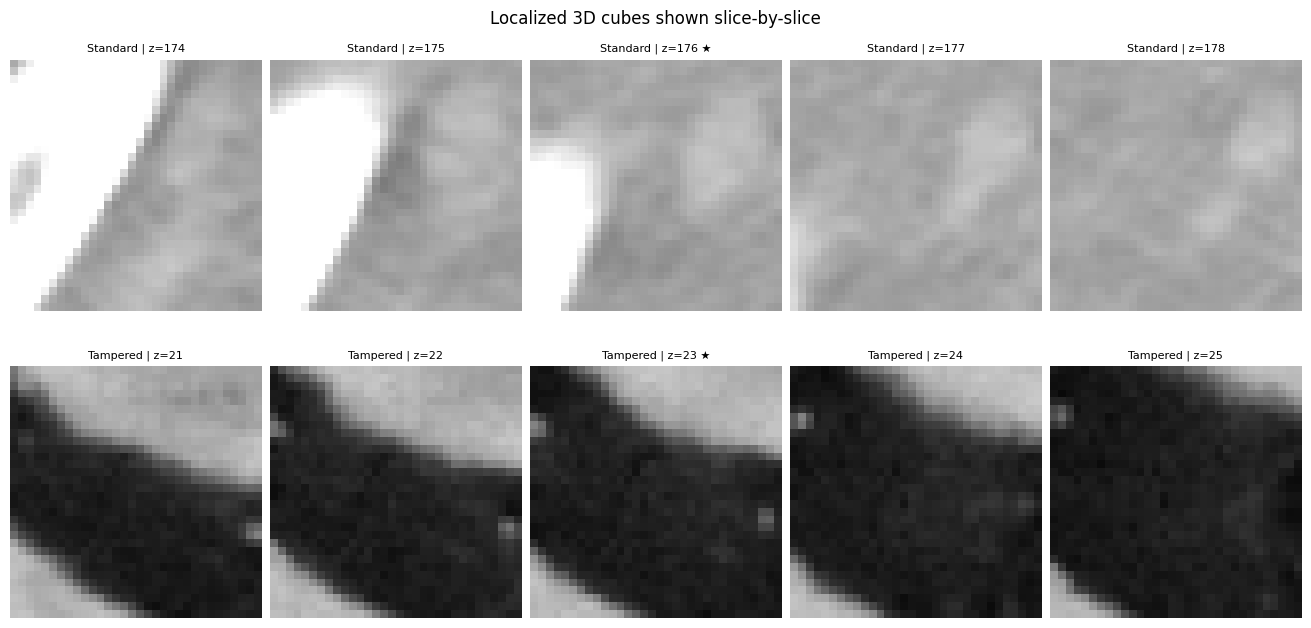

In [12]:
# Visualize one standard cube and one tampered cube across depth
examples = []
for target_value, label_name in [(0, "Standard"), (1, "Tampered")]:
    subset = train_cube_df[train_cube_df["target"] == target_value]
    if len(subset) > 0:
        examples.append((label_name, subset.sample(n=1, random_state=CFG.seed + target_value).iloc[0]))

fig, axes = plt.subplots(len(examples), CFG.cube_depth, figsize=(2.6 * CFG.cube_depth, 3.2 * len(examples)), constrained_layout=True)
if len(examples) == 1:
    axes = np.array(axes).reshape(1, CFG.cube_depth)

for row_idx, (label_name, row) in enumerate(examples):
    volume_path = resolve_volume_path(CFG.export_root, str(row["uuid"]), str(row["source"]))
    volume = np.load(volume_path, mmap_mode="r", allow_pickle=False)[CFG.volume_key]
    center_z = int(row["slice"]); center_x = int(row["x"]); center_y = int(row["y"])
    half_depth = CFG.cube_depth // 2
    z_indices = [max(0, min(volume.shape[0] - 1, center_z + dz)) for dz in range(-half_depth, half_depth + 1)]

    for col_idx, z in enumerate(z_indices):
        patch = train_cube_ds._crop_2d_patch(volume[z], center_x, center_y)
        ax = axes[row_idx, col_idx]
        ax.imshow(patch, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{label_name} | z={z}" + (" ★" if z == center_z else ""), fontsize=8)
        ax.axis("off")

plt.suptitle("Localized 3D cubes shown slice-by-slice", fontsize=12)
plt.show()

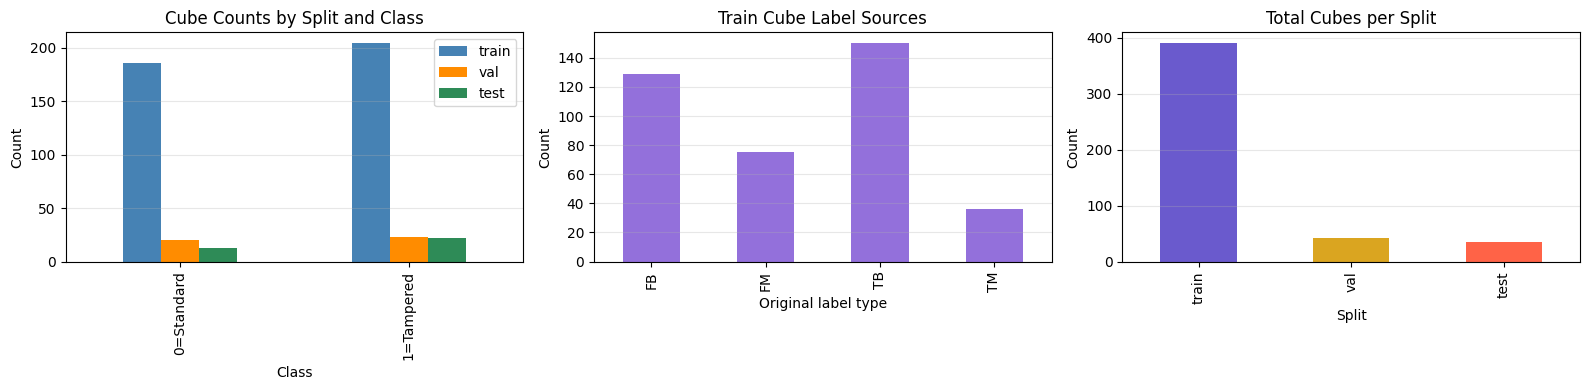

Train / Val / Test scan counts:
{'train': 60, 'val': 20, 'test': 20}

Train cube distribution by target:
target
0=Standard    186
1=Tampered    204
Name: count, dtype: int64


In [13]:
# Cube-level distribution summary
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cube_distribution.plot(kind="bar", ax=axes[0], color=["steelblue", "darkorange", "seagreen"])
axes[0].set_title("Cube Counts by Split and Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)

train_cube_df["type"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    title="Train Cube Label Sources",
    color="mediumpurple",
 )
axes[1].set_xlabel("Original label type")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.3)

pd.concat([
    train_cube_df.assign(split="train"),
    val_cube_df.assign(split="val"),
    test_cube_df.assign(split="test"),
])["split"].value_counts().plot(
    kind="bar",
    ax=axes[2],
    title="Total Cubes per Split",
    color=["slateblue", "goldenrod", "tomato"],
 )
axes[2].set_xlabel("Split")
axes[2].set_ylabel("Count")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Train / Val / Test scan counts:")
print({
    "train": len(train_scan_df),
    "val": len(val_scan_df),
    "test": len(test_scan_df),
})

print("\nTrain cube distribution by target:")
print(train_cube_df["target"].value_counts().sort_index().rename({0: "0=Standard", 1: "1=Tampered"}))

## Localized 3D CNN

The new model is a compact 3D CNN designed for small lesion-centered cubes. It uses:

- a **full 3D stem** with `3×3×3` kernels,
- light pooling so the cube does not lose depth context too early,
- **GroupNorm** for stable training with moderate batch sizes, and
- a simple global pooling head, since the cube is already tightly focused around a candidate point.

In [14]:
def _group_count(channels: int) -> int:
    for groups in (8, 4, 2, 1):
        if channels % groups == 0:
            return groups
    return 1


class ResidualBlock3D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, stride: Tuple[int, int, int] = (1, 1, 1)):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.norm1 = nn.GroupNorm(_group_count(out_ch), out_ch)
        self.act1 = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.norm2 = nn.GroupNorm(_group_count(out_ch), out_ch)
        self.act2 = nn.SiLU(inplace=True)

        if stride != (1, 1, 1) or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv3d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.GroupNorm(_group_count(out_ch), out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.skip(x)
        x = self.act1(self.norm1(self.conv1(x)))
        x = self.norm2(self.conv2(x))
        return self.act2(x + identity)


class LocalCube3DCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(_group_count(16), 16),
            nn.SiLU(inplace=True),
        )
        self.layer1 = ResidualBlock3D(16, 32)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2))
        self.layer2 = ResidualBlock3D(32, 64)
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 2))
        self.layer3 = ResidualBlock3D(64, 96)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool3d((1, 1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.30),
            nn.Linear(96, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.layer1(x)
        x = self.pool1(x)
        x = self.layer2(x)
        x = self.pool2(x)
        x = self.layer3(x)
        return self.head(x).squeeze(1)


model = LocalCube3DCNN().to(CFG.device)

n_neg = int((train_cube_df["target"] == 0).sum())
n_pos = int((train_cube_df["target"] == 1).sum())
pos_weight_val = max(1.0, n_neg / max(n_pos, 1))
pos_weight_tensor = torch.tensor([pos_weight_val], dtype=torch.float32, device=CFG.device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.cube_lr, weight_decay=CFG.cube_weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=CFG.cosine_T0,
    T_mult=CFG.cosine_T_mult,
    eta_min=CFG.cosine_eta_min,
 )

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")
print(f"Training pos_weight: {pos_weight_val:.3f}")

with torch.no_grad():
    sample_x, _ = train_cube_ds[0]
    sample_logits = model(sample_x.unsqueeze(0).to(CFG.device))
print(f"Sanity forward pass: logits shape={tuple(sample_logits.shape)}")

LocalCube3DCNN(
  (stem): Sequential(
    (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    (1): GroupNorm(8, 16, eps=1e-05, affine=True)
    (2): SiLU(inplace=True)
  )
  (layer1): ResidualBlock3D(
    (conv1): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (act1): SiLU(inplace=True)
    (conv2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
    (act2): SiLU(inplace=True)
    (skip): Sequential(
      (0): Conv3d(16, 32, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
      (1): GroupNorm(8, 32, eps=1e-05, affine=True)
    )
  )
  (pool1): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  (layer2): ResidualBlock3D(
    (conv1): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bi

In [15]:
# One-batch smoke test: confirms loss/backprop run before the full training loop
xb_smoke, yb_smoke = next(iter(train_loader))
xb_smoke = xb_smoke.to(CFG.device)
yb_smoke = yb_smoke.to(CFG.device)

model.train()
optimizer.zero_grad(set_to_none=True)
logits_smoke = model(xb_smoke)
loss_smoke = criterion(logits_smoke, yb_smoke)
loss_smoke.backward()
grad_norm_smoke = 0.0
for param in model.parameters():
    if param.grad is not None:
        grad_norm_smoke += float(param.grad.detach().norm().item())
optimizer.zero_grad(set_to_none=True)

print(f"Smoke-test cube batch shape: {tuple(xb_smoke.shape)}")
print(f"Smoke-test loss: {loss_smoke.item():.4f}")
print(f"Aggregate gradient norm: {grad_norm_smoke:.4f}")

Smoke-test cube batch shape: (24, 1, 5, 32, 32)
Smoke-test loss: 0.7692
Aggregate gradient norm: 520465078.5398


In [24]:
def collect_cube_predictions(
    model: nn.Module,
    loader: DataLoader,
    device: str,
) -> Tuple[List[int], List[float]]:
    model.eval()
    all_labels: List[int] = []
    all_probs: List[float] = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits)
            all_labels.extend(yb.numpy().astype(int).tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    return all_labels, all_probs


def evaluate_cube_model(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: str,
    threshold: float = 0.5,
) -> Tuple[float, float, float, float, float]:
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += loss.item() * xb.size(0)

    labels, probs = collect_cube_predictions(model, loader, device)
    preds = (np.asarray(probs) >= threshold).astype(int)
    avg_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(labels, preds)
    bal_acc = balanced_accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    try:
        roc = roc_auc_score(labels, probs)
    except ValueError:
        roc = float("nan")
    return avg_loss, float(acc), float(bal_acc), float(macro_f1), float(roc)


history: Dict[str, List[float]] = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": [],
    "val_f1": [],
    "val_auc": [],
    "val_threshold": [],
    "lr": [],
}

eval_threshold = 0.50
best_model_score = -1.0
best_threshold = eval_threshold
epochs_no_improve = 0
best_state_dict: Optional[Dict[str, torch.Tensor]] = None

print(f"{'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>9} {'Acc':>6} {'BalAcc':>7} {'F1':>6} {'AUC':>6} {'Thr':>6} {'LR':>9}")
print("-" * 79)

for epoch in range(CFG.cube_epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(CFG.device), yb.to(CFG.device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_acc, val_bal_acc, val_f1, val_auc = evaluate_cube_model(
        model,
        val_loader,
        criterion,
        CFG.device,
        threshold=eval_threshold,
    )

    scheduler.step(epoch + 1)
    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_bal_acc"].append(val_bal_acc)
    history["val_f1"].append(val_f1)
    history["val_auc"].append(val_auc)
    history["val_threshold"].append(eval_threshold)
    history["lr"].append(current_lr)

    print(
        f"{epoch + 1:5d} {train_loss:10.4f} {val_loss:9.4f} {val_acc:6.3f} "
        f"{val_bal_acc:7.3f} {val_f1:6.3f} {val_auc:6.3f} {eval_threshold:6.2f} {current_lr:9.2e}"
    )

    model_score = val_auc + 0.10 * val_f1
    if model_score > best_model_score + CFG.cube_min_delta:
        best_model_score = model_score
        epochs_no_improve = 0
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= CFG.cube_early_stop_patience:
            print(
                f"\nEarly stopping triggered at epoch {epoch + 1} "
                f"(best validation score={best_model_score:.4f}, threshold={eval_threshold:.2f})"
            )
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"\nRestored best validation weights (score={best_model_score:.4f}, threshold={best_threshold:.2f})")

CFG.weights_dir.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "best_model_score": best_model_score,
        "best_threshold": best_threshold,
        "epochs_trained": len(history["epoch"]),
        "cube_depth": CFG.cube_depth,
        "cube_patch_size": CFG.cube_patch_size,
    },
    CFG.cube_weights_path,
 )
print(f"\nSaved best localized 3D cube weights to {CFG.cube_weights_path}")

Epoch  TrainLoss   ValLoss    Acc  BalAcc     F1    AUC    Thr        LR
-------------------------------------------------------------------------------
    1     0.3777    0.8337  0.558   0.545  0.533  0.648   0.50  2.89e-04
    2     0.2880    0.7617  0.558   0.541  0.521  0.774   0.50  2.56e-04
    3     0.2747    0.7166  0.628   0.629  0.628  0.735   0.50  2.08e-04
    4     0.2947    0.9089  0.628   0.610  0.590  0.763   0.50  1.50e-04
    5     0.2737    1.1307  0.535   0.510  0.449  0.663   0.50  9.33e-05
    6     0.1608    0.8716  0.628   0.613  0.602  0.743   0.50  4.48e-05
    7     0.1724    1.0447  0.581   0.560  0.523  0.726   0.50  1.24e-05
    8     0.1911    0.7893  0.674   0.663  0.660  0.759   0.50  3.00e-04
    9     0.1772    1.3701  0.488   0.463  0.394  0.711   0.50  2.97e-04
   10     0.2343    0.7936  0.558   0.541  0.521  0.796   0.50  2.89e-04
   11     0.1851    1.2385  0.488   0.466  0.417  0.674   0.50  2.75e-04
   12     0.1953    0.9296  0.581   0.570  0

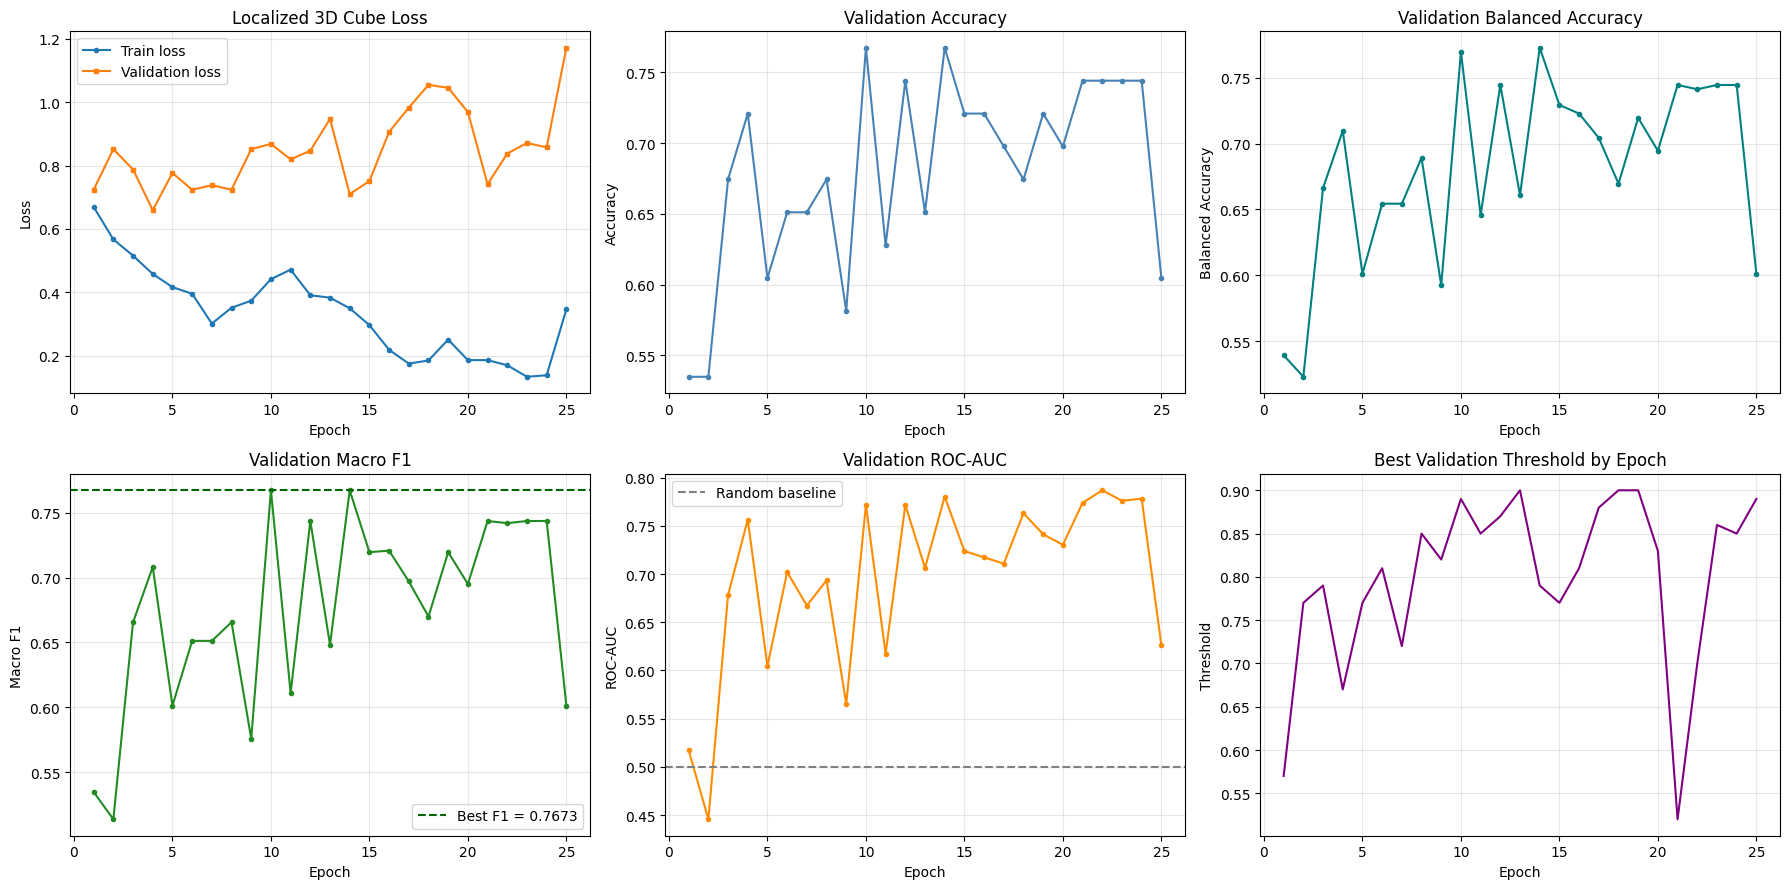

In [ ]:
hist = history

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

axes[0].plot(hist["epoch"], hist["train_loss"], marker="o", markersize=3, label="Train loss")
axes[0].plot(hist["epoch"], hist["val_loss"], marker="s", markersize=3, label="Validation loss")
axes[0].set_title("Localized 3D Cube Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(hist["epoch"], hist["val_acc"], marker="o", markersize=3, color="steelblue")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)

axes[2].plot(hist["epoch"], hist["val_bal_acc"], marker="o", markersize=3, color="teal")
axes[2].set_title("Validation Balanced Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Balanced Accuracy")
axes[2].grid(True, alpha=0.3)

axes[3].plot(hist["epoch"], hist["val_f1"], marker="o", markersize=3, color="forestgreen")
axes[3].axhline(max(hist["val_f1"]), linestyle="--", color="darkgreen", label=f"Best F1 = {max(hist['val_f1']):.4f}")
axes[3].set_title("Validation Macro F1")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("Macro F1")
axes[3].grid(True, alpha=0.3)
axes[3].legend()

axes[4].plot(hist["epoch"], hist["val_auc"], marker="o", markersize=3, color="darkorange")
axes[4].axhline(max(hist["val_auc"]), linestyle="--", color="saddlebrown", label=f"Best AUC = {max(hist['val_auc']):.4f}")
axes[4].set_title("Validation ROC-AUC")
axes[4].set_xlabel("Epoch")
axes[4].set_ylabel("ROC-AUC")
axes[4].grid(True, alpha=0.3)
axes[4].legend()

axes[5].plot(hist["epoch"], hist["val_threshold"], color="purple", lw=1.5)
axes[5].set_title("Evaluation Threshold (fixed)")
axes[5].set_xlabel("Epoch")
axes[5].set_ylabel("Threshold")
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cube-Level Evaluation

All metrics below are now computed **once per localized 3D cube**. This matches the new task: given a candidate point `(slice, x, y)`, classify the surrounding 3D cube as standard or tampered.

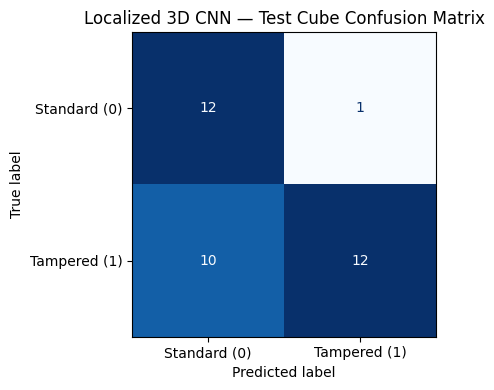

Classification Report (test cubes):
              precision    recall  f1-score   support

    Standard     0.5455    0.9231    0.6857        13
    Tampered     0.9231    0.5455    0.6857        22

    accuracy                         0.6857        35
   macro avg     0.7343    0.7343    0.6857        35
weighted avg     0.7828    0.6857    0.6857        35

Fixed evaluation threshold: 0.50


In [30]:
# Confusion matrix + classification report on the held-out test cubes
test_labels, test_probs = collect_cube_predictions(model, test_loader, CFG.device)
test_preds = (np.asarray(test_probs) >= best_threshold).astype(int).tolist()

cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Standard (0)", "Tampered (1)"],
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Localized 3D CNN — Test Cube Confusion Matrix")
plt.tight_layout()
plt.show()

print("Classification Report (test cubes):")
print(
    classification_report(
        test_labels,
        test_preds,
        target_names=["Standard", "Tampered"],
        digits=4,
        zero_division=0,
    )
)
print(f"Fixed evaluation threshold: {best_threshold:.2f}")

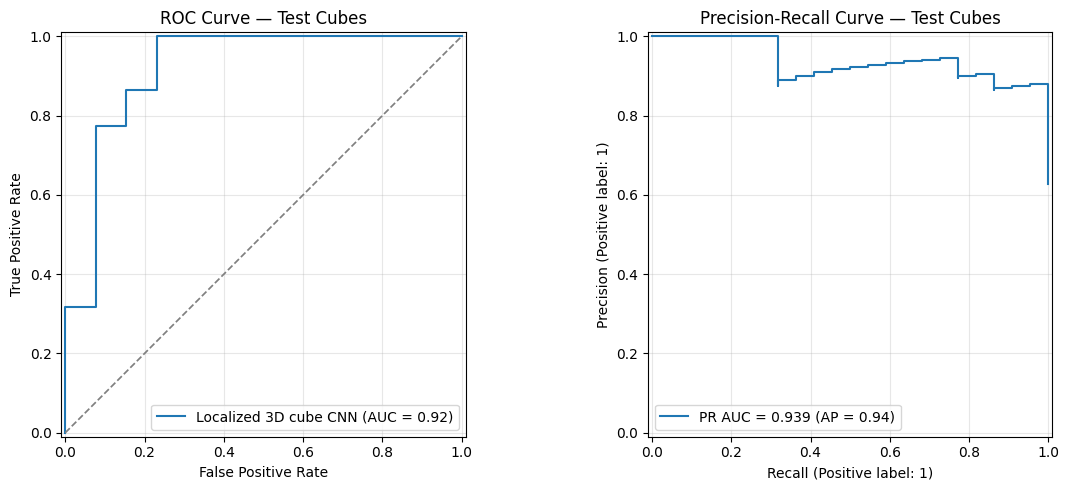

Test ROC-AUC: 0.9196
Test PR-AUC:  0.9387
Per-class precision: [0.54545455 0.92307692]
Per-class recall:    [0.92307692 0.54545455]


In [26]:
# ROC and precision-recall curves on the test cubes
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)
precision, recall, f1_per_class, support = precision_recall_fscore_support(
    test_labels,
    test_preds,
    average=None,
    zero_division=0,
 )
pr_auc = average_precision_score(test_labels, test_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="Localized 3D cube CNN").plot(ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", lw=1.25)
axes[0].set_title("ROC Curve — Test Cubes")
axes[0].grid(True, alpha=0.3)

PrecisionRecallDisplay.from_predictions(
    test_labels,
    test_probs,
    name=f"PR AUC = {pr_auc:.3f}",
    ax=axes[1],
 )
axes[1].set_title("Precision-Recall Curve — Test Cubes")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test PR-AUC:  {pr_auc:.4f}")
print(f"Per-class precision: {precision}")
print(f"Per-class recall:    {recall}")

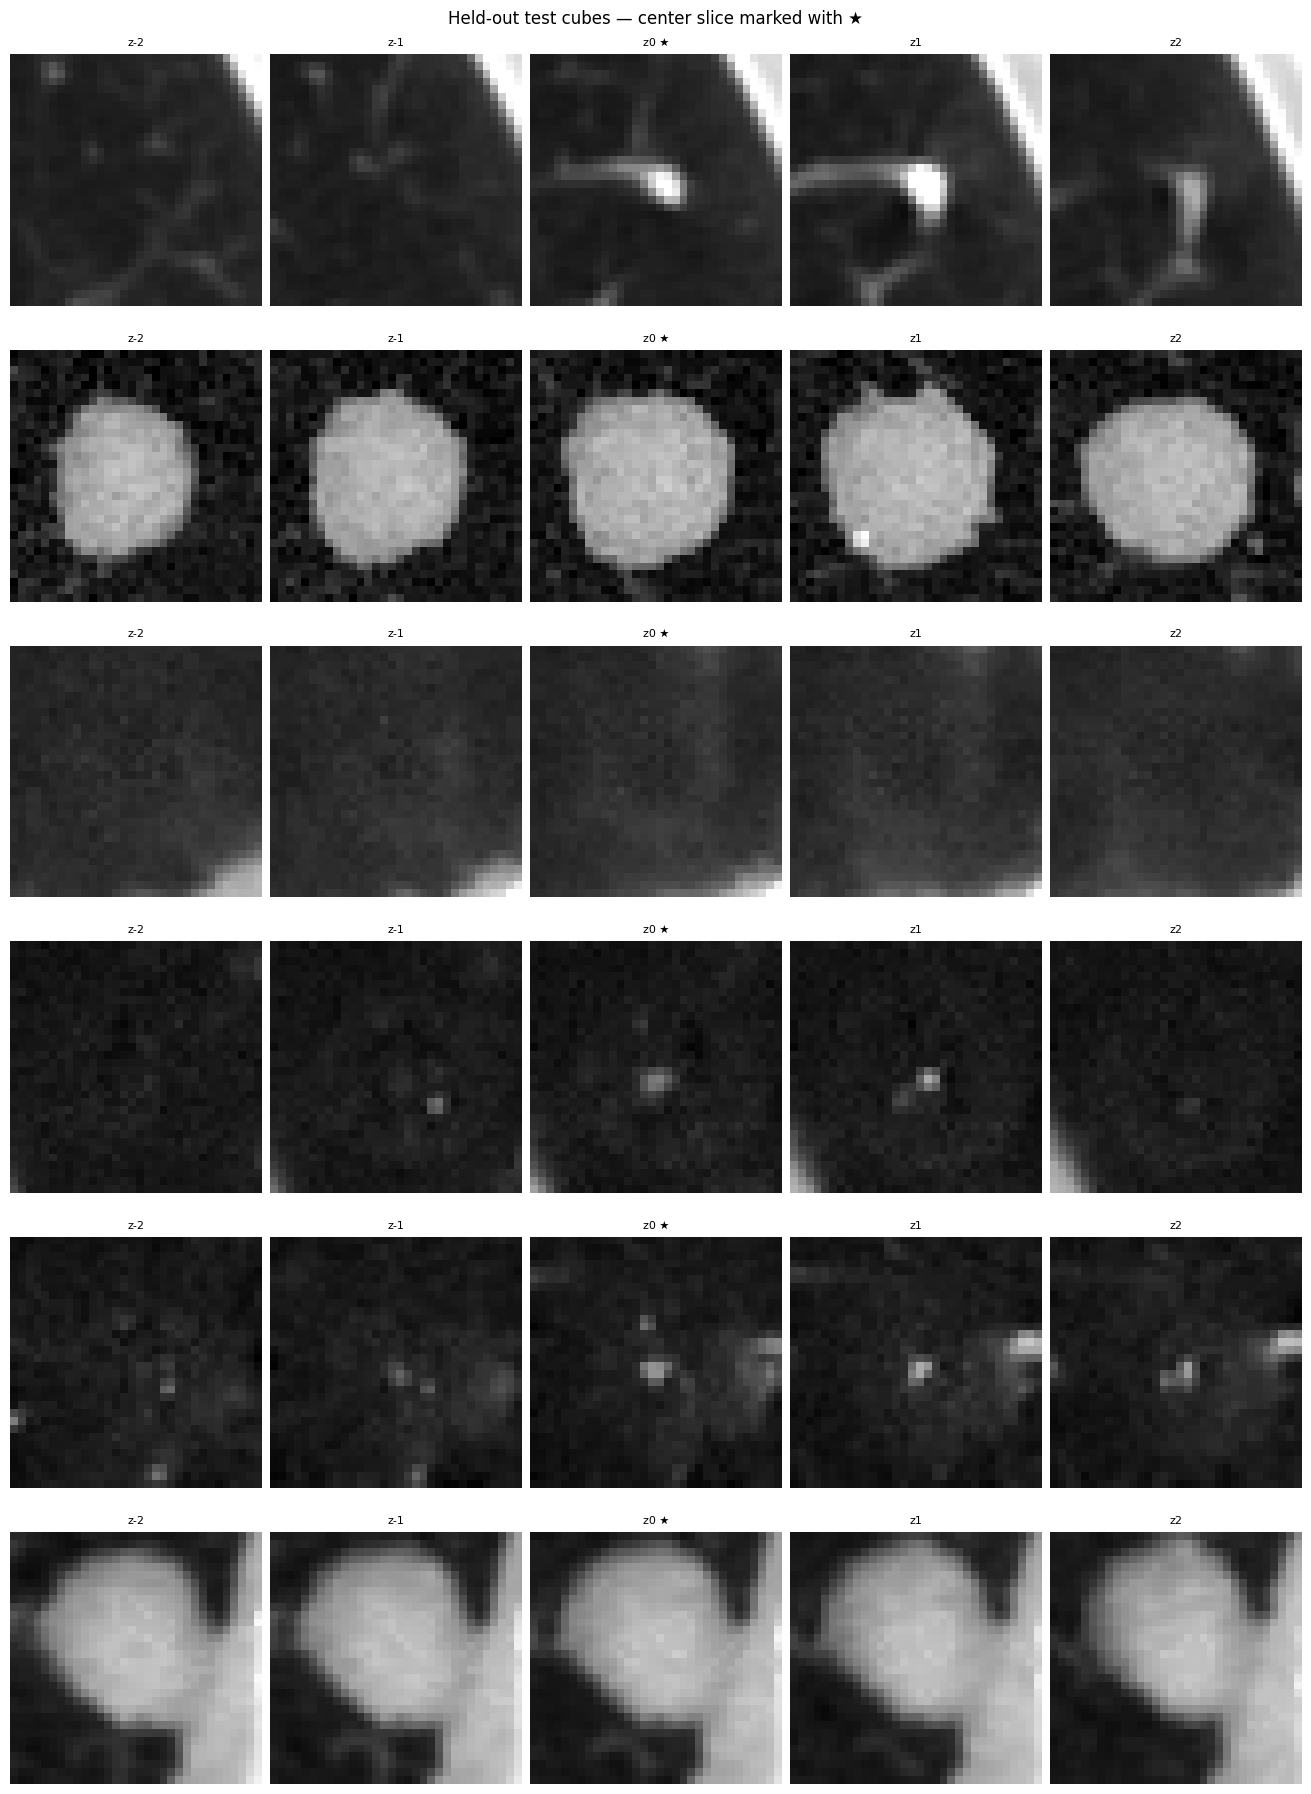

In [20]:
# Sample cube-level predictions shown slice-by-slice
n_show = min(6, len(test_cube_ds))
sample_indices = np.random.default_rng(CFG.seed).choice(len(test_cube_ds), size=n_show, replace=False)
fig, axes = plt.subplots(n_show, CFG.cube_depth, figsize=(2.6 * CFG.cube_depth, 3.0 * n_show), constrained_layout=True)
if n_show == 1:
    axes = np.array(axes).reshape(1, CFG.cube_depth)

for row_idx, idx in enumerate(sample_indices):
    cube_tensor, true_label = test_cube_ds[int(idx)]
    cube = cube_tensor.squeeze(0).numpy()
    prob = float(test_probs[int(idx)])
    pred = int(test_preds[int(idx)])
    true_int = int(true_label.item())
    meta_row = test_cube_ds.df.iloc[int(idx)]

    for col_idx in range(CFG.cube_depth):
        ax = axes[row_idx, col_idx]
        ax.imshow(cube[col_idx], cmap="gray", vmin=0, vmax=1)
        title = f"z{col_idx - CFG.cube_depth // 2}"
        if col_idx == CFG.cube_depth // 2:
            title += " ★"
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    axes[row_idx, 0].set_ylabel(
        f"{meta_row['type']} | {'T' if true_int else 'S'}→{'T' if pred else 'S'}\nP={prob:.2f}",
        fontsize=8,
        color="green" if pred == true_int else "red",
    )

plt.suptitle("Held-out test cubes — center slice marked with ★", fontsize=12)
plt.show()

Total cube-level misclassifications: 11 / 35


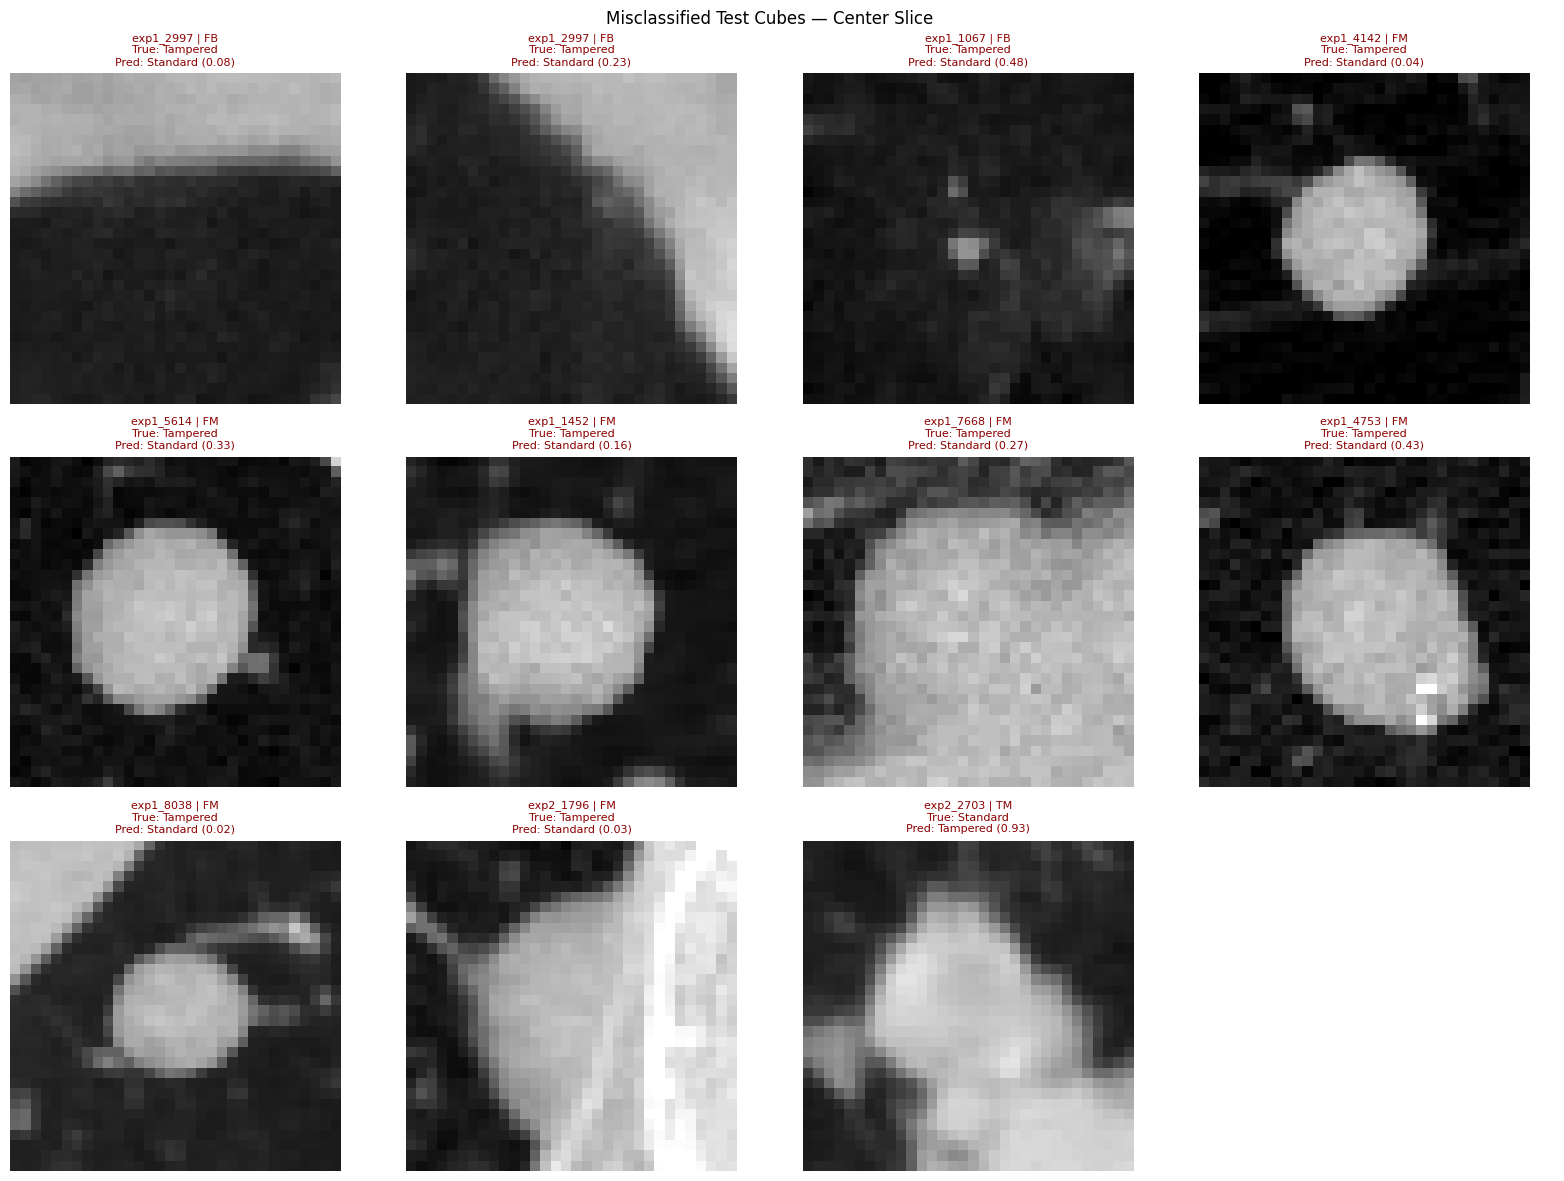

In [28]:
# Visualize all misclassified test cubes
misclassified = []
for idx, (true_label, pred_label, prob) in enumerate(zip(test_labels, test_preds, test_probs)):
    if int(true_label) != int(pred_label):
        meta_row = test_cube_ds.df.iloc[idx]
        misclassified.append(
            {
                "idx": idx,
                "true": int(true_label),
                "pred": int(pred_label),
                "prob": float(prob),
                "label_type": str(meta_row["type"]),
                "scan_id": f"{meta_row['source']}_{meta_row['uuid']}",
                "slice": int(meta_row["slice"]),
            }
        )

print(f"Total cube-level misclassifications: {len(misclassified)} / {len(test_cube_ds)}")

if misclassified:
    cols = min(4, len(misclassified))
    rows = int(np.ceil(len(misclassified) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).ravel()

    for ax, item in zip(axes, misclassified):
        cube_tensor, _ = test_cube_ds[item["idx"]]
        cube = cube_tensor.squeeze(0).numpy()
        mid_z = cube.shape[0] // 2
        ax.imshow(cube[mid_z], cmap="gray", vmin=0, vmax=1)
        ax.set_title(
            f"{item['scan_id']} | {item['label_type']}\nTrue: {'Tampered' if item['true'] else 'Standard'}\n"
            f"Pred: {'Tampered' if item['pred'] else 'Standard'} ({item['prob']:.2f})",
            fontsize=8,
            color="darkred",
        )
        ax.axis("off")

    for ax in axes[len(misclassified):]:
        ax.axis("off")

    plt.suptitle("Misclassified Test Cubes — Center Slice", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified test cubes to display.")


def predict_single_cube(source: str, uuid: str, slice_idx: int, x: int, y: int) -> float:
    """Manual ROI helper: score one candidate cube with the trained model."""
    temp_df = pd.DataFrame([
        {
            "source": str(source),
            "uuid": str(uuid),
            "slice": int(slice_idx),
            "x": int(x),
            "y": int(y),
            "target": 0,
            "type": "MANUAL",
        }
    ])
    temp_csv = CFG.export_root / "_manual_cube_query.csv"
    temp_df.to_csv(temp_csv, index=False)

    query_ds = CTCubeDataset3D(
        CFG.export_root,
        temp_csv,
        cube_depth=CFG.cube_depth,
        patch_size=CFG.cube_patch_size,
        augment=False,
        jitter_xy=0,
        jitter_z=0,
        volume_key=CFG.volume_key,
    )
    cube_tensor, _ = query_ds[0]
    with torch.no_grad():
        prob = torch.sigmoid(model(cube_tensor.unsqueeze(0).to(CFG.device))).item()
    return float(prob)

In [29]:
# Final train / validation / test metrics at cube level
_, train_acc, train_bal_acc, train_f1, train_auc = evaluate_cube_model(model, train_loader, criterion, CFG.device, threshold=best_threshold)
_, val_acc, val_bal_acc, val_f1, val_auc = evaluate_cube_model(model, val_loader, criterion, CFG.device, threshold=best_threshold)
_, test_acc, test_bal_acc, test_f1, test_auc = evaluate_cube_model(model, test_loader, criterion, CFG.device, threshold=best_threshold)

test_majority_baseline = max(
    (test_cube_df["target"] == 0).mean(),
    (test_cube_df["target"] == 1).mean(),
)

print("=" * 72)
print(f"{'Metric':<24} {'Train':>10} {'Val':>10} {'Test':>10}")
print("-" * 72)
print(f"{'Accuracy':<24} {train_acc:>10.4f} {val_acc:>10.4f} {test_acc:>10.4f}")
print(f"{'Balanced Accuracy':<24} {train_bal_acc:>10.4f} {val_bal_acc:>10.4f} {test_bal_acc:>10.4f}")
print(f"{'Macro F1':<24} {train_f1:>10.4f} {val_f1:>10.4f} {test_f1:>10.4f}")
print(f"{'ROC-AUC':<24} {train_auc:>10.4f} {val_auc:>10.4f} {test_auc:>10.4f}")
print("=" * 72)

print(f"\nTest majority-class cube baseline : {test_majority_baseline:.4f}")
print(f"Fixed evaluation threshold        : {best_threshold:.2f}")
print(f"Test accuracy                     : {test_acc:.4f}")
print(f"Test macro F1                     : {test_f1:.4f}")
print(f"Saved checkpoint                  : {CFG.cube_weights_path}")

Metric                        Train        Val       Test
------------------------------------------------------------------------
Accuracy                     0.8744     0.8140     0.6857
Balanced Accuracy            0.8724     0.8261     0.7343
Macro F1                     0.8718     0.8114     0.6857
ROC-AUC                      0.9934     0.8174     0.9196

Test majority-class cube baseline : 0.6286
Fixed evaluation threshold        : 0.50
Test accuracy                     : 0.6857
Test macro F1                     : 0.6857
Saved checkpoint                  : /Users/ningkaiyang/Desktop/CS 172B Project/model_weights/local_cube_3d_cnn.pt


In [23]:
# Threshold sweep diagnostic for current run
threshold_rows = []
for thr in np.linspace(0.1, 0.9, 17):
    preds_thr = (np.asarray(test_probs) >= thr).astype(int)
    threshold_rows.append({
        "threshold": float(thr),
        "acc": accuracy_score(test_labels, preds_thr),
        "bal_acc": balanced_accuracy_score(test_labels, preds_thr),
        "f1": f1_score(test_labels, preds_thr, average="macro", zero_division=0),
        "positive_rate": float(preds_thr.mean()),
    })

pd.DataFrame(threshold_rows).sort_values(["f1", "bal_acc", "acc"], ascending=False).head(10)

,threshold,acc,bal_acc,f1,positive_rate
8,0.50,0.885714,0.861888,0.873188,0.685714
9,0.55,0.885714,0.861888,0.873188,0.685714
2,0.20,0.885714,0.846154,0.867424,0.742857
3,0.25,0.885714,0.846154,0.867424,0.742857
4,0.30,0.885714,0.846154,0.867424,0.742857
5,0.35,0.885714,0.846154,0.867424,0.742857
6,0.40,0.885714,0.846154,0.867424,0.742857
7,0.45,0.885714,0.846154,0.867424,0.742857
10,0.60,0.857143,0.839161,0.844444,0.657143
11,0.65,0.857143,0.839161,0.844444,0.657143
